# U.S. Personal Savings & Macroeconomic Conditions (Post-COVID)

## Who is this analysis for?
This analysis is intended for **everyday American consumers** who want to understand the drivers that either encourage or discourage saving, as well as their **personal finance advisors**. No preexisting economics background is presumed.

## Research Question
How have U.S. personal savings rates shifted since the COVID-19 pandemic, and which macroeconomic conditions -- including unemployment, inflation, consumer sentiment, and income -- are most associated with Americans saving more or less?

## Motivation
The personal savings rate spiked to ~32% in April 2020 (CARES Act stimulus + lockdown spending suppression), then collapsed below pre-pandemic norms in 2022. For a consumer, recognizing the macro signals that tend to precede a savings drop can inform personal savings behavior (e.g., a rise in interest rates can precipitate investment rebalancing in favor of bonds). For a personal finance advisor, identifying the conditions correlated with low savings helps predict and proactively mitigate client financial stress.

## Data Source
All data is pulled from **FRED (Federal Reserve Economic Data)**, a free public database maintained by the Federal Reserve Bank of St. Louis. FRED provides standardized, seasonally-adjusted economic series that are regularly updated, making it an ideal source for macroeconomic analysis. We pull 12 monthly series spanning **January 2015 through December 2024** -- five years of pre-COVID baseline, two years of COVID shock, and three years of post-COVID normalization.

| Series ID  | Description                                              | Why Included                                    |
|------------|----------------------------------------------------------|-------------------------------------------------|
| PSAVERT    | Personal Savings Rate (%)                                | Primary variable of interest                    |
| UNRATE     | Unemployment Rate (%)                                    | Key labor-market indicator                      |
| CPIAUCSL   | Consumer Price Index (All Urban, SA)                     | Inflation pressure on saving capacity           |
| UMCSENT    | U. Michigan Consumer Sentiment Index                     | Forward-looking consumer confidence             |
| DSPIC96    | Real Disposable Personal Income                          | Income actually available to save               |
| FEDFUNDS   | Effective Federal Funds Rate (%)                         | Interest-rate environment for savers            |
| PCEPI      | PCE Price Index                                          | Alternative inflation gauge (Fed-preferred)     |
| RSAFS      | Advance Retail Sales (millions, SA)                      | Consumer spending, an inverse proxy for saving    |
| REVOLSL    | Revolving Consumer Credit Outstanding (billions, SA) ★   | Direct counter-signal to savings                |
| CSUSHPISA  | S&P/Case-Shiller U.S. National Home Price Index ★        | Household wealth and housing-cost context       |
| AHETPI     | Avg Hourly Earnings -- Production & Nonsupervisory ★      | Wage trajectory and real purchasing power       |
| HOUST      | Privately-Owned Housing Starts (SAAR, thousands) ★       | Big-ticket commitment that competes with saving |

★ New for final

## Economic Eras
- **Pre-COVID (2015–2019):** Stable, low-volatility baseline
- **COVID (2020–2021):** Historic savings spike driven by stimulus and reduced spending
- **Post-COVID (2022–2024):** Savings decline as inflation and spending rebound

## Section 2 -- API Data Pull

This section pulls 12 monthly seasonally-adjusted FRED series (the 8 from the midterm plus 4 new ones) and merges them into a single time-indexed dataframe (fred_df).

In [1]:
import requests
import json
from pprint import pprint
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, accuracy_score,
    precision_score, recall_score, roc_auc_score, confusion_matrix)
from math import sqrt

In [2]:
# Authentication step
API_KEY = "952be1cf27e40becb80f7f3945ff49cf"

In [3]:
# Search FRED metadata to confirm our series exist and are monthly
url_search = 'https://api.stlouisfed.org/fred/series/search'

params_search = {
    'search_text': 'personal saving rate',
    'api_key': API_KEY,
    'file_type': 'json'
}

response_search = requests.get(url_search, params = params_search)
print(response_search.status_code)

200


In [4]:
# Normalize JSON into a dataframe for easy inspection
search_df = pd.json_normalize(response_search.json()['seriess'])
search_df[['id', 'title', 'frequency', 'seasonal_adjustment']].head(10)

,id,title,frequency,seasonal_adjustment
0,PSAVERT,Personal Saving Rate,Monthly,Seasonally Adjusted Annual Rate
1,PMSAVE,Personal Saving,Monthly,Seasonally Adjusted Annual Rate
2,PSAVE,Personal Saving,Quarterly,Seasonally Adjusted Annual Rate
3,A071RC1A027NBEA,Personal saving,Annual,Not Seasonally Adjusted
4,A072RC1Q156SBEA,Personal saving as a percentage of disposable ...,Quarterly,Seasonally Adjusted Annual Rate
5,A072RC1A156NBEA,Personal saving as a percentage of disposable ...,Annual,Not Seasonally Adjusted
6,ESAVINGSBR0101,Bankrate Consumer Survey Poll: How Long Would ...,"Annual, As of May",Not Seasonally Adjusted
7,BOGZ1FA156007015Q,Households and Nonprofit Organizations; Person...,"Quarterly, End of Period",Seasonally Adjusted Annual Rate
8,BOGZ1FA156007015A,Households and Nonprofit Organizations; Person...,"Annual, End of Period",Seasonally Adjusted Annual Rate
9,BOGZ1FU156007015Q,Households and Nonprofit Organizations; Person...,"Quarterly, End of Period",Not Seasonally Adjusted


The search above illustrates how we used FRED's series search endpoint to verify that 'PSAVERT' (Personal Savings Rate) is available at **monthly frequency** and is **seasonally adjusted** -- the two criteria required for all 12 series to merge cleanly on a shared data column. We identified the remaining 11 series by browsing FRED's website directly, checking for the same frequency and seasonal adjustment parameters (these are prominently featured at the top of every series homepage).

In [5]:
# Helper function: Pull one FRED series and return a clean two-column dataframe
def pull_fred_series(series_id, col_name, api_key, start = '2015-01-01', end = '2024-12-31'):
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': start,
        'observation_end': end
    }
    response = requests.get(url, params = params)
    print(f'{series_id}: status {response.status_code}')

    series_df = pd.DataFrame(response.json()['observations'])

    # Clean: Strip whitespace, replace FRED's '.' placeholder with NaN, and convert types
    series_df['value'] = series_df['value'].str.strip()
    series_df['value'] = series_df['value'].replace('.', float('nan'))
    series_df['value'] = pd.to_numeric(series_df['value'], errors = 'coerce')
    series_df['date'] = pd.to_datetime(series_df['date'])

    # Keep only the two columns we need and rename value to the series name
    series_df = series_df[['date', 'value']].rename(columns = {'value': col_name})
    return series_df

In [6]:
# Pull all 12 series
savings_rate = pull_fred_series('PSAVERT', 'savings_rate', API_KEY)
unemployment_rate = pull_fred_series('UNRATE', 'unemployment_rate', API_KEY)
cpi = pull_fred_series('CPIAUCSL', 'cpi', API_KEY)
consumer_sentiment = pull_fred_series('UMCSENT', 'consumer_sentiment', API_KEY)
real_disp_income = pull_fred_series('DSPIC96', 'real_disposable_income', API_KEY)
fed_funds_rate = pull_fred_series('FEDFUNDS', 'fed_funds_rate', API_KEY)
pce_price_index = pull_fred_series('PCEPI', 'pce_price_index', API_KEY)
retail_sales = pull_fred_series('RSAFS', 'retail_sales', API_KEY)
revolving_credit = pull_fred_series('REVOLSL',   'revolving_credit',  API_KEY)  # NEW
home_price_index = pull_fred_series('CSUSHPISA', 'home_price_index',  API_KEY)  # NEW
hourly_earnings  = pull_fred_series('AHETPI',    'hourly_earnings',   API_KEY)  # NEW
housing_starts   = pull_fred_series('HOUST',     'housing_starts',    API_KEY)  # NEW

PSAVERT: status 200
UNRATE: status 200
CPIAUCSL: status 200
UMCSENT: status 200
DSPIC96: status 200
FEDFUNDS: status 200
PCEPI: status 200
RSAFS: status 200
REVOLSL: status 200
CSUSHPISA: status 200
AHETPI: status 200
HOUST: status 200


In [7]:
# Merge all 12 series on date to preserve all months
fred_df = savings_rate
for series in [unemployment_rate, cpi, consumer_sentiment, real_disp_income, fed_funds_rate, pce_price_index, retail_sales, revolving_credit, home_price_index, hourly_earnings, housing_starts]:
    fred_df = pd.merge(fred_df, series, on='date')

# Set date as the index, sorted chronologically
fred_df = fred_df.set_index('date').sort_index()

# Quick confirmation; should expect ~120 rows and 12 columns
print(fred_df.shape)
fred_df.head()

(120, 12)


,savings_rate,unemployment_rate,cpi,consumer_sentiment,real_disposable_income,fed_funds_rate,pce_price_index,retail_sales,revolving_credit,home_price_index,hourly_earnings,housing_starts
date,,,,,,,,,,,,
2015-01-01,6.3,5.7,234.747,98.1,13797.7,0.11,96.654,428208.0,881033.59,168.612,20.80,1085.0
2015-02-01,6.4,5.5,235.342,95.4,13848.0,0.11,96.825,427119.0,884751.64,169.104,20.84,886.0
2015-03-01,5.9,5.4,235.976,93.0,13811.3,0.11,97.008,433647.0,890777.97,169.776,20.91,960.0
2015-04-01,5.9,5.4,236.222,95.9,13842.0,0.12,97.094,434470.0,898602.06,170.278,20.92,1190.0
2015-05-01,5.8,5.6,237.001,90.7,13865.6,0.12,97.327,437865.0,900342.45,170.862,20.98,1079.0


**Note on the while loop:** For larger datasets where a single API call cannot return all observations, we would increment an 'offset' parameter in a while loop until the full dataset is retrieved. Since each of our 12 series spans only ~120 monthly observations -- well under FRED's 100k-row-per-call limit -- a single call per series is sufficient.

'fred_df' is now ready for inspection in Section 3.

## Section 3 -- Initial Data Inspection

We conduct standard numeric data-quality checks for fred_df to confirm it loaded correctly and to flag anything that will need addressing in Section 4. No changes are made to the data here, as this section is only for observation.

In [8]:
# Confirm overall shape and column names
fred_df.shape, fred_df.columns

((120, 12),
 Index(['savings_rate', 'unemployment_rate', 'cpi', 'consumer_sentiment',
        'real_disposable_income', 'fed_funds_rate', 'pce_price_index',
        'retail_sales', 'revolving_credit', 'home_price_index',
        'hourly_earnings', 'housing_starts'],
       dtype='str'))

'fred_df' has 120 rows and 12 columns, consistent with monthly observations from January 2015 through December 2024. All 12 expected series are present as columns.

In [9]:
# Schema check -- data types and non-null counts
fred_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 120 entries, 2015-01-01 to 2024-12-01
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   savings_rate            120 non-null    float64
 1   unemployment_rate       120 non-null    float64
 2   cpi                     120 non-null    float64
 3   consumer_sentiment      120 non-null    float64
 4   real_disposable_income  120 non-null    float64
 5   fed_funds_rate          120 non-null    float64
 6   pce_price_index         120 non-null    float64
 7   retail_sales            120 non-null    float64
 8   revolving_credit        120 non-null    float64
 9   home_price_index        120 non-null    float64
 10  hourly_earnings         120 non-null    float64
 11  housing_starts          120 non-null    float64
dtypes: float64(12)
memory usage: 12.2 KB


'.info()' confirms all 12 value columns loaded as 'float64' and that the index loaded as 'DatetimeIndex'. The non-null counts tell us whether any column has missing values; if all show 120 non-null, we know that the data is complete!

In [10]:
# Summary statistics across all 12 series
fred_df.describe()

,savings_rate,unemployment_rate,cpi,consumer_sentiment,real_disposable_income,fed_funds_rate,pce_price_index,retail_sales,revolving_credit,home_price_index,hourly_earnings,housing_starts
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,1.200000e+02,120.000000,120.000000,120.000000
mean,7.150000,4.682500,266.973700,83.192500,15856.535833,1.782583,107.505550,549218.558333,1.062322e+06,236.376392,24.801333,1336.566667
std,4.321162,1.733198,26.410624,14.289011,1365.735931,1.873314,9.066018,96057.497420,1.334307e+05,53.220252,3.074614,188.757046
min,2.200000,3.400000,234.747000,50.000000,13797.700000,0.050000,96.654000,401028.000000,8.810336e+05,168.612000,20.800000,886.000000
25%,5.400000,3.700000,244.230500,70.450000,14649.825000,0.127500,99.793750,465119.750000,9.603627e+05,191.197750,22.057500,1191.750000
50%,5.900000,4.100000,257.098500,89.050000,15742.500000,1.155000,103.983000,511604.500000,1.026825e+06,214.456500,23.880000,1305.500000
75%,6.925000,5.000000,294.924000,96.125000,16961.525000,2.402500,116.632750,659624.250000,1.122600e+06,297.905250,27.555000,1483.000000
max,31.800000,14.800000,317.604000,101.400000,20520.000000,5.330000,124.979000,717265.000000,1.352434e+06,327.532000,30.660000,1807.000000


Summary statistics show plausible ranges across all 12 series. 'Savings rate' has a maximum of 31.8% -- well above its mean of 7.2% -- indicating at least one extreme observation that we will investigate further in Section 4.

In [11]:
# Missing value check
fred_df.isna().sum()

savings_rate              0
unemployment_rate         0
cpi                       0
consumer_sentiment        0
real_disposable_income    0
fed_funds_rate            0
pce_price_index           0
retail_sales              0
revolving_credit          0
home_price_index          0
hourly_earnings           0
housing_starts            0
dtype: int64

All 12 series merged cleanly into a 120 x 12 frame. The missing value check returns zero across every column; no imputation will be needed.

## Section 4 -- Data Cleaning

We create fred_clean from fred_df, applying a defensive dropna() and adding two integer helper columns (year, month) extracted from the datetime index. If FRED's source data were ever updated with gaps, the dropna() ensures 'fred_clean' remains complete without requiring changes to later sections. We choose 'dropna()' over 'fillna()' because this is monthly macroeconomic data from a reliable government source; a missing observation reflects a MCAR data point, which means it is a true reporting gap that is safe to drop. The helper columns allow downstream groupby operations to run directly without repeating the extraction logic.

Section 3 confirmed zero missing values or anomalies, so no rows will be lost. The April 2020 savings spike (~31.8%) outlier is retained as an actual economic event assumed to be catalyzed by the CARES Act stimulus.

In [12]:
# Defensive dropna and copy -- no rows lost, confirmed via Section 3
fred_clean = fred_df.dropna().copy()
print('Rows before dropna:', len(fred_df))
print('Rows after dropna:', len(fred_clean))

Rows before dropna: 120
Rows after dropna: 120


In [13]:
# Extract year and month as integer helper columns for downstream groupbys
fred_clean['year'] = fred_clean.index.year
fred_clean['month'] = fred_clean.index.month

In [14]:
# Confirm final fred_clean shape
fred_clean.shape

(120, 14)

fred_clean is now the analysis-ready dataframe for all downstream sections -- 120 rows and 14 columns (12 economic series plus year and month helpers). No rows were lost during cleaning, consistent with Section 3's zero missing-value count.

The SQLite handoff cells below write fred.db so the SQL notebook can run all 12 queries without re-pulling from the API or duplicating any cleaning logic.

### SQLite Handoff

These cells write fred.db with three tables:
1) fred_monthly_long: the long-format fact table (1,440 rows -- 120 months x 12 series)
2) period_lookup: maps each year to its economic era (Pre-COVID / COVID / Post-COVID)
3) series_metadata: maps each FRED series ID to a human-readable name, units, and category

The SQL notebook opens fred.db directly; no API code and no cleaning code is duplicated there. Run the Python notebook first to generate fred.db, then run the SQL notebook.

In [15]:
# Melt fred_clean to long format and map column names to FRED IDs
value_columns = ['savings_rate', 'unemployment_rate', 'cpi', 'consumer_sentiment',
                 'real_disposable_income', 'fed_funds_rate', 'pce_price_index', 'retail_sales',
                 'revolving_credit', 'home_price_index', 'hourly_earnings', 'housing_starts']

fred_long = fred_clean.reset_index().melt(
    id_vars = ['date', 'year', 'month'], value_vars = value_columns,
    var_name = 'series_id', value_name = 'value')

column_to_series_id = {
    'savings_rate':'PSAVERT', 'unemployment_rate':'UNRATE', 'cpi':'CPIAUCSL',
    'consumer_sentiment':'UMCSENT', 'real_disposable_income':'DSPIC96',
    'fed_funds_rate':'FEDFUNDS','pce_price_index':'PCEPI', 'retail_sales':'RSAFS',
    'revolving_credit': 'REVOLSL', 'home_price_index':'CSUSHPISA',
    'hourly_earnings':'AHETPI', 'housing_starts':'HOUST'
}
fred_long['series_id'] = fred_long['series_id'].map(column_to_series_id)

In [16]:
# Build period_lookup -- year to era mapping for SQL joins
period_lookup = pd.DataFrame({
    'year': list(range(2015, 2025)),
    'period': ['Pre-COVID']*5 + ['COVID']*2 + ['Post-COVID']*3
})                        

In [17]:
# Build series_metadata -- FRED ID to readable name, units, and category
series_metadata = pd.DataFrame({
    'series_id': list(column_to_series_id.values()),
    'series_name': ['Personal Savings Rate', 'Unemployment Rate', 'CPI',
                    'Consumer Sentiment', 'Real Disposable Income', 'Fed Funds Rate',
                    'PCE Price Index', 'Retail Sales', 'Revolving Credit',
                    'Home Price Index', 'Hourly Earnings', 'Housing Starts'],
    'units': ['%', '%', 'Index', 'Index', 'billions', '%', 'Index', 'millions',
              'billions', 'Index', 'dollars', 'thousands'],
    'category': ['Saving', 'Labor', 'Inflation', 'Sentiment', 'Income', 'Rates',
                 'Inflation', 'Spending', 'Credit', 'Wealth', 'Wages', 'Housing']
})

In [18]:
# Write all three tables to fred.db
conn = sqlite3.connect('fred.db')
fred_long.to_sql('fred_monthly_long', conn, if_exists = 'replace', index = False)
period_lookup.to_sql('period_lookup', conn, if_exists = 'replace', index = False)
series_metadata.to_sql('series_metadata', conn, if_exists = 'replace', index = False)
conn.close()

## Section 5 -- Developing a Preliminary Understanding of the Key Variable of Interest (Savings Rate)

We examine savings_rate, our primary variable of interest, across three lenses -- an annual aggregation table showing volatility across years, an extreme-month identification block showing the highest and lowest savings months, and a full timeline chart serving as both the primary visual and a data-quality confirmation.

In [19]:
# Annual multi-stat groupby -- mean and std for key series by year
annual_macro_stats = fred_clean.groupby('year')[
    ['savings_rate', 'unemployment_rate', 'consumer_sentiment', 'cpi']
    ].agg(['mean', 'std'])

annual_macro_stats

savings_rate           unemployment_rate           consumer_sentiment  \
             mean       std              mean       std               mean   
year                                                                         
2015     5.850000  0.257611          5.275000  0.245412          92.941667   
2016     5.358333  0.365459          4.875000  0.121543          91.841667   
2017     5.758333  0.365459          4.358333  0.167649          96.766667   
2018     6.433333  0.721530          3.891667  0.124011          98.366667   
2019     7.308333  0.677507          3.675000  0.135680          95.983333   
2020    15.091667  6.859825          8.100000  3.622656          81.541667   
2021    11.325000  5.936348          5.350000  0.870214          77.616667   
2022     3.350000  0.654356          3.650000  0.156670          58.975000   
2023     5.591667  0.320393          3.625000  0.142223          65.350000   
2024     5.433333  0.615457          4.025000  0.160255          72.541667   

                        cpi            
            std        mean       std  
year                                   
2015   3.044356  237.001750  1.145957  
2016   2.915931  240.005417  1.740882  
2017   1.903744  245.121000  1.498123  
2018   1.571527  251.099500  1.347744  
2019   3.299265  255.652583  1.764423  
2020  10.099636  258.855750  1.900483  
2021   6.993612  270.973417  5.949585  
2022   4.912160  292.626417  5.612928  
2023   3.767686  304.703000  2.839581  
2024   4.594554  313.698167  2.229275

Given the above table, three findings emerge:

1. 2020 is the most volatile year across all four series; savings_rate's standard deviation hits 6.9 percentage points versus 0.3 in stable pre-COVID years, and consumer_sentiment's std of 10.1 is similarly outsized.
2. 2022 shows the lowest mean savings rate (3.4%) of any year in the window as well as the highest mean CPI (292.6) of any pre-2023 year -- inflation was eroding saving capacity faster than wages could compensate. Financial advisors should ensure that all client savings plans keep pace with forecasted CPI increases and feature a "buffer" for unexpected increases.
3. Consumer sentiment in 2022 is the most depressed of any non-COVID year (mean 59.0), sitting closer to recession levels than recovery even though unemployment was low at 3.7% -- a significant finding for advisors managing client expectations.

In [20]:
# Top 5 highest savings months
fred_clean['savings_rate'].sort_values(ascending = False).head()

date
2020-04-01    31.8
2021-03-01    26.2
2020-05-01    22.6
2021-01-01    19.5
2020-06-01    18.3
Name: savings_rate, dtype: float64

In [21]:
# Bottom 5 lowest savings months
fred_clean['savings_rate'].sort_values(ascending = True).head()

date
2022-06-01    2.2
2022-04-01    2.6
2022-05-01    2.6
2022-03-01    3.2
2022-08-01    3.2
Name: savings_rate, dtype: float64

The top 5 savings months are all 2020–2021 stimulus months. April 2020 (~31.8%) leads, driven by CARES Act payments landing while lockdowns suppressed spending. The bottom 5 are all 2022, clustered around 3% -- defining the post-COVID floor that consumers and advisors should benchmark against today.

The most important implication is that the COVID spike is a one-time event as opposed to a new baseline. Given that the post-COVID floor is materially lower than the pre-COVID norm, any planning conversation anchored on pre-2020 averages is likely to overstate how easy it is for a typical household to save today.

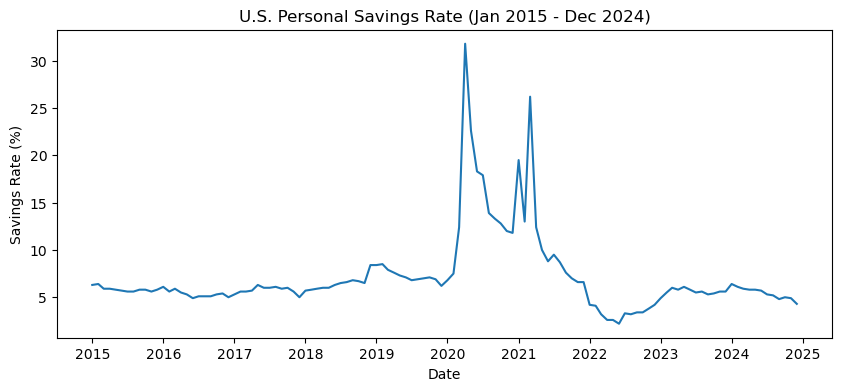

In [22]:
# Savings rate over time -- primary visual and data quality confirmation
plt.figure(figsize = (10, 4))
sns.lineplot(x = fred_clean.index, y = fred_clean['savings_rate'])
plt.xlabel('Date')
plt.ylabel('Savings Rate (%)')
plt.title('U.S. Personal Savings Rate (Jan 2015 - Dec 2024)')
plt.savefig('savings_rate_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

The line chart explicates the entire narrative: A stable pre-COVID baseline around 6 - 8%, the April 2020 spike to 32%, a secondary bump in early 2021 (third
stimulus round), then a steep descent that falls below the pre-pandemic baseline by
mid-2022 and stays there through 2024.

Because every observation is plotted, the chart also confirms data quality as there are no flat segments, no gaps, and no discontinuities outside the COVID window.

## Section 6 -- Broadening Our Analytical Scope to Understand Movement Between Savings Rates and Related Series

With the initial savings_rate findings established in Section 5, this section investigates: Which macro neighbors move with savings, which move against, and how does the era backdrop differ?

We build a period column, rank correlations numerically, examine era-level averages, then visualize the relationships across three charts.

In [23]:
# Assign economic era labels via .map()
year_to_period = {
    2015: 'Pre-COVID', 2016: 'Pre-COVID', 2017: 'Pre-COVID',
    2018: 'Pre-COVID', 2019: 'Pre-COVID',
    2020: 'COVID', 2021: 'COVID',
    2022: 'Post-COVID', 2023: 'Post-COVID', 2024: 'Post-COVID'
}

fred_clean['period'] = fred_clean['year'].map(year_to_period)

In [24]:
# Confirm period labels and expected counts
fred_clean['period'].value_counts()

period
Pre-COVID     60
Post-COVID    36
COVID         24
Name: count, dtype: int64

We use .map() to translate the integer year column into era labels. The value_counts() confirms the expected 60 / 36 / 24 split across Pre-COVID, Post-COVID, and COVID months.

In [25]:
# Rank correlations between all series and savings_rate
ranked_corr = (
    fred_clean.corr(numeric_only = True)['savings_rate']
    .drop(['savings_rate', 'year', 'month'])
    .sort_values()
)

ranked_corr

fed_funds_rate           -0.304692
revolving_credit         -0.262908
retail_sales             -0.185435
cpi                      -0.170484
pce_price_index          -0.166041
home_price_index         -0.138098
hourly_earnings          -0.055426
housing_starts            0.008383
consumer_sentiment        0.033641
real_disposable_income    0.381209
unemployment_rate         0.825505
Name: savings_rate, dtype: float64

On the negative side, fed_funds_rate is the most negatively correlated series (-0.30), followed closely by revolving_credit (-0.26). The fed funds result is counterintuitive at first -- higher rates should incentivize saving -- but reflects the post-COVID period, when the Fed was aggressively hiking rates precisely because savings had already collapsed and inflation was running hot. The two variables moved in opposite directions not because rates discourage saving, but because both were responding to the same underlying shock. As such, financial advisors should carefully evaluate the causal / contextual factors driving federal funds rate increases given that rising inflation may diminish clients' ability to save. Revolving credit's negative correlation is more straightforward: When households borrow more on credit cards, they are saving less by definition. Retail sales (-0.19) and the price indices (-0.17 and -0.17) follow the same logic -- higher spending and higher prices both leave less room to save.

On the positive side, unemployment_rate shows the strongest positive correlation with savings_rate at 0.83 -- by far the largest magnitude in either direction. As flagged above, this is entirely a feature of COVID: Stimulus checks landed while lockdowns suppressed spending, causing both unemployment and savings to spike simultaneously. This is a prime example of why correlation must always be interpreted in context! Real disposable income (0.38) is the more economically meaningful positive signal because more take-home income supports saving capacity. Consumer sentiment (0.03) and housing_starts (0.01) are essentially uncorrelated with savings over this window.

In [26]:
# Multi-variable era backdrop -- mean of key series by economic period
era_macro_means = fred_clean.groupby('period')[
    ['savings_rate', 'unemployment_rate', 'real_disposable_income', 'fed_funds_rate',
    'revolving_credit', 'retail_sales', 'cpi', 'pce_price_index', 'home_price_index']
].mean()

era_macro_means

,savings_rate,unemployment_rate,real_disposable_income,fed_funds_rate,revolving_credit,retail_sales,cpi,pce_price_index,home_price_index
period,,,,,,,,,
COVID,13.208333,6.725000,16940.445833,0.227917,9.902313e+05,555022.208333,264.914583,106.819500,241.025375
Post-COVID,4.791667,3.766667,17076.355556,3.950278,1.234499e+06,677319.888889,303.675861,120.092389,308.477833
Pre-COVID,6.141667,4.415000,14691.080000,1.103833,9.878515e+05,470036.300000,245.776050,100.227867,191.255933


This table is the "macro weather report" for each era. A few findings stand out:

Post-COVID is the least favorable savings environment of the three -- mean savings_rate of just 4.8%, lower than even the Pre-COVID baseline of 6.1%. What makes this particularly interesting is that real_disposable_income is actually highest in the Post-COVID era (17k), meaning households are earning more in nominal terms but still saving less. The culprit is visible in the remaining columns: CPI (304), pce_price_index (120), and home_price_index (308) are all at their highest levels, revolving_credit has jumped to 1.23M (versus 988K Pre-COVID), and retail_sales are the highest of any era. In short, whatever income gains exist are being offset by inflation, housing costs, and spending.

COVID shows the anomaly clearly: Savings spikes to 13.2% while fed_funds_rate sits near zero (0.23%) and unemployment is elevated (6.7%), the opposite of what normal macro relationships would predict. Stimulus payments combined with lockdown-suppressed spending drove savings up regardless of the rate environment.

Pre-COVID serves as the stable comparator: Moderate savings (6.1%), low unemployment (4.4%), low fed funds (1.1%), and the lowest price levels across all three indices.

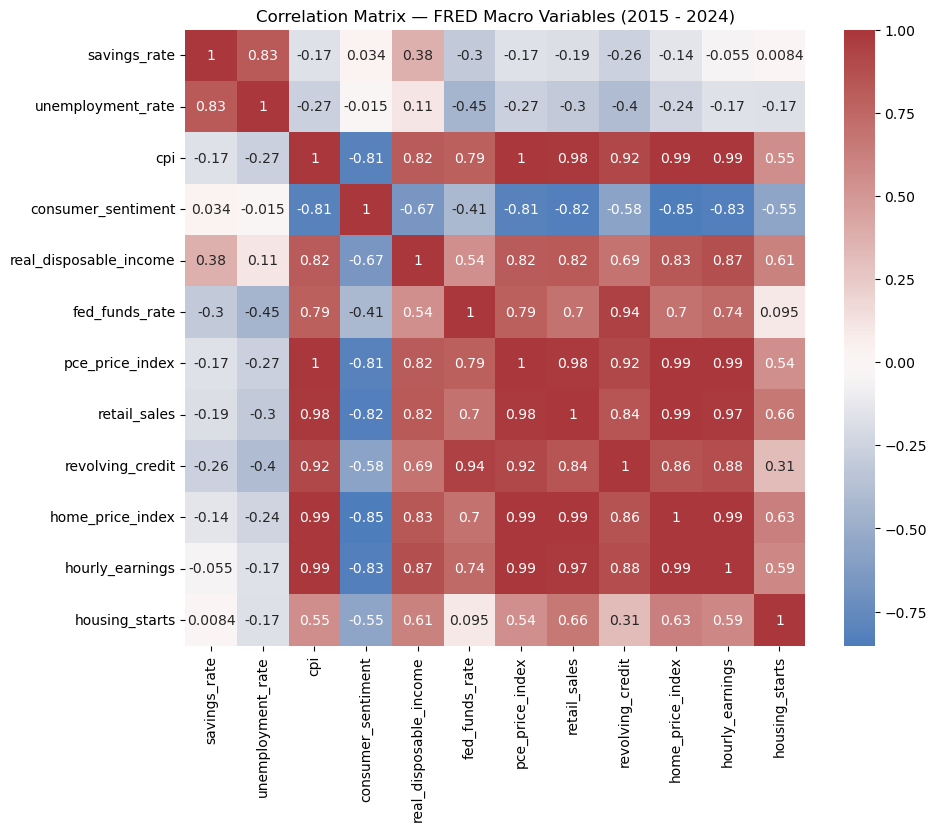

In [27]:
# Correlation heatmap across all 12 FRED series
plt.figure(figsize=(10, 8))
sns.heatmap(fred_clean.drop(columns = ['year', 'month']).corr(numeric_only = True), annot = True, cmap = 'vlag', center = 0)
plt.title('Correlation Matrix — FRED Macro Variables (2015 - 2024)')
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap shows every pairwise relationship across all 12 series in one image. Reading the savings_rate row confirms the initial ranked correlations -- the deep red cell with unemployment_rate (0.83) reflects the COVID "coupling", while the moderate red with real_disposable_income (0.38) represents the more meaningful (and intuitive!) economic relationship. The blue cells along the savings_rate row -- fed_funds_rate (-0.30), revolving_credit (-0.26), retail_sales (-0.19) -- identify the series that move against saving.

The heatmap also reveals the broader macro structure: The cluster of deep red cells among CPI, PCE, retail_sales, home_price_index, and hourly_earnings shows that all
of these price and spending variables move nearly in lockstep, as they are all expressions of the same underlying inflationary trend. Consumer_sentiment stands out as the lone deep blue column across that same cluster, confirming it moves in the opposite direction to inflation. Financial advisors should note that a drop in consumer optimism may hence point to an increased willingness to save.

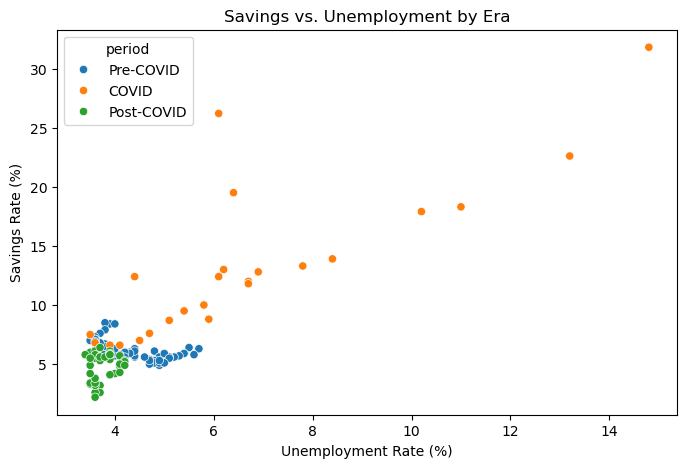

In [28]:
# Savings vs. unemployment, colored by economic era
plt.figure(figsize = (8, 5))
sns.scatterplot(data = fred_clean, x = 'unemployment_rate', y = 'savings_rate', hue = 'period')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Savings Rate (%)')
plt.title('Savings vs. Unemployment by Era')
plt.savefig('savings_vs_unemployment_by_era', dpi=150, bbox_inches='tight')
plt.show()

The era coloring makes the COVID decoupling immediately visible across three distinct clusters. Pre-COVID points (blue) form a tight horizontal band at moderate savings (5 - 9%) and low unemployment (3.5 - 5.5%) -- stable, predictable behavior that advisors could reliably anchor client conversations on. Post-COVID points (green) occupy the same low unemployment range but sit noticeably lower on the y-axis (2–6%) -- the same labor market conditions producing worse saving outcomes, which is a key finding of this analysis.

COVID points (orange) tell a completely different story. As unemployment rises from 4% to 15%, savings rises with it, the opposite of what normal macro relationships would predict. This is the stimulus effect: The orange cluster fans upward and to the right, peaking at ~32% savings when unemployment was at its highest. No pre- or post-COVID month comes close to that range on either axis.

Financial advisors and clients that see this chart should immediately understand why a single correlation coefficient between savings and unemployment is misleading, because the relationship is positive during COVID and essentially flat outside of it. The context that era-driven analysis provides is critical.

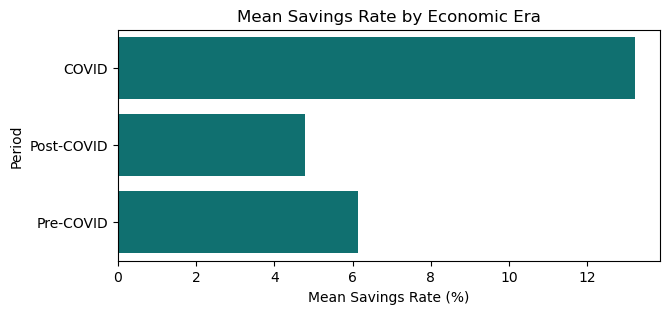

In [29]:
# Mean savings rate by economic era
era_savings_means = fred_clean.groupby('period')['savings_rate'].mean().reset_index()

plt.figure(figsize = (7,3))
sns.barplot(data = era_savings_means, x = 'savings_rate', y = 'period', orient = 'h', color = 'teal')
plt.xlabel('Mean Savings Rate (%)')
plt.ylabel('Period')
plt.title('Mean Savings Rate by Economic Era')
plt.savefig('mean_savings_rate_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

This chart depicts the mean savings rate in each era. COVID is highest (driven by stimulus), Pre-COVID is a comfortable second, and Post-COVID is the lowest. This is the single most efficient chart for the presentation!

For a personal finance advisor, this chart demonstrates that today's clients are saving at a rate notably below what pre-pandemic data would predict. This is a key takeaway from this analysis.

## Section 7 -- Normalizing Data Using Ratios and Introducing Broader Time Horizons

This section builds new variables in order to conduct more granular analyses using normalized data. We add two ratio columns (savings_to_income_ratio, credit_to_income_ratio), a boolean dummy (is_covid_period), a binary label derived via .apply() (savings_tier), and one-hot encoded era columns.

In [30]:
# Savings-to-income ratio -- savings rate relative to disposable income
fred_clean['savings_to_income_ratio'] = (
    fred_clean['savings_rate'] / fred_clean['real_disposable_income']
)

In [31]:
# Credit-to-income ratio -- revolving credit relative to disposable income
fred_clean['credit_to_income_ratio'] = (
    fred_clean['revolving_credit'] / fred_clean['real_disposable_income']
)

In [32]:
# Boolean dummy identifying the COVID shock period (2020 - 2021)
fred_clean['is_covid_period'] = (
    (fred_clean['year'] == 2020) | (fred_clean['year'] == 2021)
)

In [33]:
# Binary savings-tier label -- high or low relative to the median
savings_median = fred_clean['savings_rate'].median()
fred_clean['savings_tier'] = fred_clean['savings_rate'].apply(
    lambda r: 'high' if r > savings_median else 'low'
)

In [34]:
# One-hot encode the period column -- creates fred_features for modeling
fred_features = pd.get_dummies(fred_clean, columns = ['period'], drop_first = True)

In [35]:
# Outlier check -- min and max of both engineered ratios
for col in ['savings_to_income_ratio', 'credit_to_income_ratio']:
    print(col, 'min =', fred_clean[col].min(), 'max =', fred_clean[col].max())

savings_to_income_ratio min = 0.00013696156982861128 max = 0.001765166275332634
credit_to_income_ratio min = 46.39769980506823 max = 75.93462339631117


The two ratios operate on completely different scales. savings_to_income_ratio ranges from 0.00014 to 0.00177 -- very small numbers because savings_rate is a percentage (e.g. 6.0) being divided by real_disposable_income measured in billions of dollars (e.g. ~15,000). The ratio is still analytically valid -- it moves consistently with saving behavior -- but the raw values are not intuitively meaningful on their own. This is exactly why we decide to use MinMaxScaler in subsequent analysis: It rescales both ratios to the same [0, 1] range before feeding them into the models, preventing the credit_to_income_ratio's much larger scale from dominating the coefficients.

Credit_to_income_ratio ranges from 46.4 to 75.9, reflecting revolving credit outstanding (in millions) divided by real disposable income (in billions), a units mismatch that produces large raw values. Again, the direction of movement is what matters analytically: Higher values indicate households are carrying more borrowed credit relative to their income, which the Section 6 correlations confirmed moves against saving behavior.

In [36]:
# Top 5 highest savings_to_income_ratio months
fred_clean['savings_to_income_ratio'].sort_values(ascending = False).head()

date
2020-04-01    0.001765
2020-05-01    0.001321
2021-03-01    0.001277
2020-06-01    0.001073
2021-01-01    0.001072
Name: savings_to_income_ratio, dtype: float64

All 5 top months are 2020 - 2021 stimulus months, with April 2020 leading at 0.00177. As noted in the outlier audit above, the raw values are small due to the units mismatch between savings_rate and real_disposable_income -- but the relative ordering is what matters analytically. The same COVID months that dominated the savings_rate extreme-month table in Section 5 appear here in the same order, confirming the ratio is behaving consistently with the underlying data.

In [37]:
# Multi-variable comparison across COVID vs. non-COVID periods
covid_window_means = fred_clean.groupby('is_covid_period')[
    ['savings_rate', 'consumer_sentiment', 'revolving_credit']
    ].mean()

covid_window_means

,savings_rate,consumer_sentiment,revolving_credit
is_covid_period,,,
False,5.635417,84.095833,1.080344e+06
True,13.208333,79.579167,9.902313e+05


The two-row table illustrates a clean binary contrast across three variables. During the COVID period (True), the average savings_rate was 13.2%, more than double the 5.6% average outside it (False). This confirms the COVID window as an anomaly.

The revolving_credit result demonstrates the opposite narrative: During COVID, households carried less revolving credit (990M) than outside of it (1.08B). When stimulus checks are landing and spending opportunities are limited, households both save more AND borrow less simultaneously; the two behaviors reinforce each other.

The consumer_sentiment result is intuitive on reflection. COVID months show lower average sentiment (79.6) than non-COVID months (84.1), with savings dramatically higher during COVID. When consumers feel uncertain about the future (e.g., in terms of job security, health, the broader economy) the natural behavioral response is to hoard cash as a precaution. Lower confidence drives precautionary saving vs. spending. For advisors, this means a drop in consumer sentiment may actually be an early signal that clients are about to increase their savings buffer, which is a useful leading indicator for planning conversations.

## Section 8 -- Additional Data Normalization and Key Metrics to Evaluate Model Robustness

This section fits two models -- a linear regression predicting savings_rate and a logistic regression predicting whether a month falls in the high-savings tier. Both
models use the engineered features from Section 7.

A note on the train/test split: We use train_test_split with random_state=42, as taught in class. With time-series data, a random split carries some risk of look-ahead leakage because training months can include observations that come after test months chronologically, meaning the model is effectively trained on future data relative to some of its test observations. However, the goal of this analysis is inferential rather than predictive; we want to interpret coefficients to identify which macro signals associate with saving more or less, not to forecast next month's savings rate. For an inferential goal, the in-class random split is appropriate. A chronological split (e.g., 2015–2022 train / 2023–2024 test) would be the right choice for a predictive application and could be addressed in future analyses.

In [38]:
# Define the model feature list
model_features = ['unemployment_rate', 'cpi', 'consumer_sentiment', 'fed_funds_rate',
                  'real_disposable_income', 'retail_sales', 'revolving_credit',
                  'home_price_index', 'hourly_earnings', 'housing_starts',
                  'period_Pre-COVID', 'period_Post-COVID']

In [39]:
# Build feature matrix and both target variables
X_features = fred_features[model_features].astype(float)
y_savings_rate = fred_features['savings_rate']
y_high_savings_tier = (fred_features['savings_tier'] == 'high').astype(int)

In [40]:
# Train / test split -- linear target
X_train, X_test, y_savings_train, y_savings_test = train_test_split(
    X_features, y_savings_rate, test_size = 0.2, random_state = 42)

In [41]:
# Train / test split -- logistic target (X splits are identical)
_, _, y_tier_train, y_tier_test = train_test_split(
    X_features, y_high_savings_tier, test_size = 0.2, random_state = 42)

### Feature Scaling

MinMaxScaler rescales every feature to the [0, 1] range by applying (value − min) / (max − min) column-by-column. We fit the scaler on the training data only so it learns each column's min and max from the train set, then apply the same fitted transformation to the test set. This prevents test-set statistics from leaking into model training.

Scaling is especially important here because our features span very different units and ranges (e.g., percentages, billions of dollars, index values, and the tiny ratio values identified in Section 7). Without scaling, features with large raw values would dominate the model coefficients regardless of their actual predictive importance. After scaling, coefficient magnitudes are directly comparable across all features.

In [42]:
# Fit MinMaxScaler on training data, transform both sets
feature_scaler = MinMaxScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

In [43]:
# Fit linear regression model
linreg_model = LinearRegression()
linreg_model.fit(X_train_scaled, y_savings_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
# Linear model metrics -- R-squared and RMSE
r2 = linreg_model.score(X_test_scaled, y_savings_test)
y_savings_pred = linreg_model.predict(X_test_scaled)
rmse = sqrt(mean_squared_error(y_savings_test, y_savings_pred))

print(f'R-squared = {r2:.3f}')
print(f'RMSE = {rmse:.3f}')

R-squared = 0.983
RMSE = 0.604


The linear model achieves R-squared = 0.983 and RMSE = 0.605 percentage points on the test set. The high R-squared reflects two properties of this dataset rather than an overfit model. First, the macro variables in fred_features are strongly collinear; as the Section 6 heatmap showed, CPI, PCE, retail sales, home prices, and hourly earnings all move nearly in tandem, giving the model redundant signals that collectively explain most of the variance in savings_rate. Second, the random train / test split scatters test months throughout the full 2015 - 2024 window, making the test set easy to interpolate from adjacent training months.

A chronological split (training on 2015 - 2022 and testing on 2023 - 2024) would give a more conservative and realistic out-of-sample estimate; this could be the focus of any future analyses. The RMSE of 0.605 percentage points may be the more pragmatic / meaningful metric as the model's typical prediction error is less than one percentage point on a variable that ranges from 3% to 32%.

In [45]:
# Linear model coefficients sorted by magnitude
linreg_coefficients = pd.DataFrame({
    'feature': model_features,
    'coef': linreg_model.coef_
}).sort_values('coef')

linreg_coefficients

,feature,coef
5,retail_sales,-19.600316
8,hourly_earnings,-8.140532
6,revolving_credit,-6.969456
2,consumer_sentiment,-1.100198
10,period_Pre-COVID,-0.257430
9,housing_starts,0.392024
11,period_Post-COVID,0.931923
1,cpi,2.320713
3,fed_funds_rate,3.034712
7,home_price_index,6.497182


The coefficient table ranks every feature by its association with savings_rate after MinMaxScaling so magnitudes are directly comparable across features despite their different original units.

On the negative side, retail_sales has by far the largest negative coefficient (-19.56): When spending is high relative to its historical range, saving is low. This is the most direct expression of the spending-versus-saving tradeoff in the model. Hourly_earnings (-8.15) and revolving_credit (-6.94) follow; higher wages appear to encourage spending rather than saving over this window, and higher revolving credit is the classic counter-signal to saving. Consumer_sentiment (-1.11) is a mild negative, consistent with the Section 7 finding that lower confidence is associated with precautionary saving.

On the positive side, real_disposable_income has the largest positive coefficient (31.23) by a wide margin. When actual take-home income is high relative to its range, saving tends to be higher. Unemployment_rate (7.55) is the second largest positive coefficient, reflecting the COVID coupling identified throughout the EDA. Home_price_index (6.51) and fed_funds_rate (3.04) are also positively associated with savings as higher home prices may encourage precautionary saving, and higher rates create stronger incentives to save.

The period dummies tell an interesting story: Period_Post-COVID (0.93) has a slightly positive coefficient while period_Pre-COVID (-0.26) is mildly negative, meaning the model associates the Post-COVID era with marginally higher savings than COVID (the reference category) after controlling for all other features; the raw era averages from Section 6 are being adjusted for the macro backdrop.

In [46]:
# Fit logistic regression model
logreg_model = LogisticRegression(max_iter = 1000)
logreg_model.fit(X_train_scaled, y_tier_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
# Generate logistic model predictions
y_tier_pred = logreg_model.predict(X_test_scaled)
y_tier_proba = logreg_model.predict_proba(X_test_scaled)[:, 1]

In [48]:
# Logistic model metrics -- accuracy, precision, recall, ROC-AUC
print(f'Accuracy = {accuracy_score(y_tier_test, y_tier_pred):.3f}')
print(f'Precision = {precision_score(y_tier_test, y_tier_pred):.3f}')
print(f'Recall = {recall_score(y_tier_test, y_tier_pred):.3f}')
print(f'ROC-AUC = {roc_auc_score(y_tier_test, y_tier_proba):.3f}')

Accuracy = 0.833
Precision = 0.909
Recall = 0.769
ROC-AUC = 0.916


The logistic model classifies months as high- or low-savings with solid performance across all four metrics.

Accuracy (0.833) means the model correctly classified 20 of the 24 test months, a strong baseline result that confirms the macro features carry a meaningful signal for identifying saving regimes.

Precision (0.909) is the most impressive result: Of the months the model labeled high-savings, 90.9% actually were high-savings.

Recall (0.769) tells the other side of the story: Of the months that actually were high-savings, the model caught 76.9% of them. It missed roughly 1 in 4 genuine high-savings months. For an advisor using this model as an early-warning signal, this means some favorable saving environments would go undetected.

ROC-AUC (0.916) is the strongest single summary of model performance as it measures the model's ability to rank months from most-likely to least-likely high-savings across every possible classification threshold, not just the default 0.5. A score of 0.916 suggests that the model is a strong ranker. The precision-recall tradeoff above is a threshold choice; a lower threshold would recover more high-savings months at the cost of more false alarms.

In [49]:
# Confusion matrix as a labeled DataFrame
confusion_summary = pd.DataFrame(
    confusion_matrix(y_tier_test, y_tier_pred),
    index = ['Actual low', 'Actual high'],
    columns = ['Pred low', 'Pred high']
)

confusion_summary

,Pred low,Pred high
Actual low,10,1
Actual high,3,10


The confusion matrix translates the four metrics above into concrete counts across the 24 test months.

The diagonal cells are correct classifications: 10 months were correctly identified as low-savings and 10 were correctly identified as high-savings; 20 correct calls total, consistent with the 83.3% accuracy reported above.

The off-diagonal cells are the mistakes. The single false positive (Actual low / Pred high) -- one low-savings month incorrectly labeled high -- is what drives the high precision score of 0.909: The model predicted high-savings 11 times and was wrong only once. The three false negatives (Actual high / Pred low) -- three genuine high-savings months the model missed -- are what holds recall back to 0.769.

For an advisor interpreting this model, the asymmetry is significant because missing a high-savings month (false negative) means a missed opportunity to flag favorable conditions to a client. Falsely flagging a low-savings month as high (false positive) risks giving a client false confidence. With only 1 false positive versus 3 false negatives, this model errs on the side of caution, as it is more likely to undercount favorable savings environments than to overcount them.

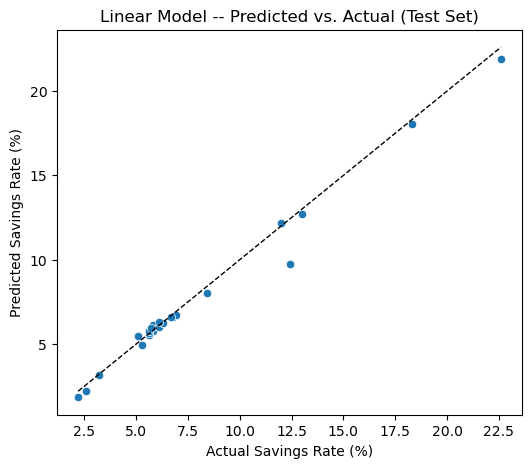

In [50]:
# Linear model diagnostic -- predicted vs. actual savings rate
plt.figure(figsize = (6,5))
sns.scatterplot(x = y_savings_test, y = y_savings_pred)
plt.plot([y_savings_test.min(), y_savings_test.max()],
        [y_savings_test.min(), y_savings_test.max()], 'k--', linewidth = 1)
plt.xlabel('Actual Savings Rate (%)')
plt.ylabel('Predicted Savings Rate (%)')
plt.title('Linear Model -- Predicted vs. Actual (Test Set)')
plt.savefig('linear_model_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

The diagnostic chart confirms the R-squared result visually. Nearly all 24 test
months sit tightly along the 45-degree reference line, indicating the model's
predictions closely track actual savings rates across the full range of the test set, from post-COVID lows around 2.5% to COVID-era highs around 22.5%.

The one notable outlier sits at approximately 12.5% actual but only 10% predicted. The model meaningfully underestimates this month. This is consistent with what we
would expect; the COVID stimulus months are the hardest observations to predict
because they were driven by one-off policy events (e.g., stimulus checks, lockdown-
suppressed spending) that the macro features alone cannot fully capture.

## Section 9 -- Conclusion

### Key Findings

The U.S. personal savings rate has undergone a structural shift since the COVID-19 pandemic that cannot be explained by income trends alone. The COVID window (2020–2021) produced a once-in-a-generation savings spike, peaking at 32% in April 2020, driven entirely by stimulus payments and lockdown-suppressed spending rather than genuine improvements in household financial health. That spike fully reversed by 2022, when the savings rate collapsed to its lowest levels in the dataset (3%), even as nominal disposable income reached its highest levels -- a pattern that points directly to inflation, rising revolving credit, and elevated spending as the drivers absorbing income gains. The post-COVID era is measurably worse for saving than the pre-COVID baseline across every macro dimension simultaneously: Higher prices, higher borrowing, higher spending, and lower savings.

### Answer to the Research Question

The macroeconomic conditions are most associated with Americans saving more or less are elevated real disposable income (coefficient +31.23), high unemployment (coefficient +7.55, a COVID-era effect), rising home prices (+6.51), and a higher fed funds rate (+3.04). The conditions most strongly associated with lower savings are high retail sales (-19.56), high hourly earnings (-8.15, suggesting wages flow into spending rather than saving over this window), and rising revolving credit (-6.94). The logistic model confirms this picture with a ROC-AUC of 0.916; the macro backdrop reliably identifies whether a given month is a high- or low-savings environment, with the caveat that the model errs toward undercounting favorable
savings conditions rather than overcounting them.

### Implications for Each Audience

**For everyday consumers:** The post-2022 savings floor (3 - 5%) is the modern benchmark as opposed to the pre-pandemic average of 6 - 7%, and certainly not the COVID spike! Any emergency fund target or savings plan anchored on pre-2020 norms is likely overstating how easy it is to save in the current environment. The macro signals most worth monitoring personally are inflation (CPI and PCE), revolving credit balances, and retail spending habits; these are the three forces the model identifies as most consistently pulling savings downward. When all three are elevated simultaneously, as they have been since 2022, building savings requires deliberate effort against the macro environment.

**For personal finance advisors:** Every measurable macro headwind has worsened in the post-pandemic period. Clients today face higher prices, higher borrowing costs, higher spending temptation, and a lower savings baseline than any comparable period in this dataset. The logistic model's precision of 0.909 means that when macro conditions align with a high-savings regime, that signal is reliable; but its recall of 0.769 means advisors should not wait for a model signal to initiate savings conversations. Proactively engaging clients when consumer sentiment drops -- the Section 7 analysis showed lower sentiment precedes higher precautionary saving -- may be the most actionable leading indicator available.

### Future Work

Five extensions would meaningfully strengthen this analysis:

**1. Chronological train/test split**
Training on 2015–2022 and testing on 2023 - 2024 would give a more conservative and realistic out-of-sample estimate of model performance, eliminating the look-ahead leakage risk inherent in the random split used here. This is the standard approach for any time-series modeling application.

**2. Additional FRED series**
Several series not included here would deepen the analysis materially:
- MORTGAGE30US (30-year fixed mortgage rate) -- housing affordability directly competes with saving capacity and is distinct from the fed funds rate
- DRCCLACBS (credit card delinquency rate) —- a leading stress indicator that substantiates revolving credit findings
- CIVPART (labor force participation rate) -— captures discouraged workers who drop out of unemployment statistics but still face income pressure
- PSAVE (personal saving in dollars) —- the level counterpart to the rate, useful for understanding aggregate household balance sheet changes

**3. State-level disaggregation**
Aggregating to the national level masks significant geographic variation. State-level FRED series on unemployment, income, and housing costs would allow the analysis to identify which regional macro conditions drive the largest deviations from the national savings rate, which is particularly relevant for advisors serving clients in high-cost-of-living markets like California or New York versus lower-cost states.

**4. External datasets beyond FRED**
Two external sources would add dimensions this dataset cannot capture:
- The Federal Reserve's Survey of Consumer Finances (SCF), published every three years, provides household-level wealth and savings data broken down by income quintile -- allowing the analysis to determine whether the post-COVID savings decline is concentrated in lower-income households or broad-based
- The BLS Consumer Expenditure Survey disaggregates spending by category (housing, food, healthcare, entertainment), which would identify which spending categories are most responsible for crowding out saving in the post-COVID period

**5. More sophisticated modeling**
- K-means clustering on the 12 macro features would identify natural groupings of months by their macro profile, potentially revealing regime patterns beyond the three hand-labeled eras used here